In [3]:
# Load Model

import pickle
import pandas as pd
import matplotlib.pyplot as plt

# Unlike tree-based models, Logistic Regression doesn't have feature_importances_. Instead, we examine its coefficients.

model = pickle.load(open("../models/placement_model.pkl", "rb"))

feature_columns = pickle.load(open("../models/feature_columns.pkl", "rb"))

In [6]:
# Get Coefficients

importance = pd.DataFrame({
    "Feature":feature_columns,
    "Coefficient":model.coef_[0]
})

importance

,Feature,Coefficient
0,age,0.004834
1,cgpa,0.026445
2,internships_count,0.128775
3,projects_count,0.126595
4,certifications_count,-0.012953
5,coding_skill_score,0.106529
6,aptitude_score,0.066407
7,communication_skill_score,0.061986
8,logical_reasoning_score,0.073852
9,hackathons_participated,0.007094


In [8]:
# Sort by Absolute Impact

importance["Absolute"] = importance["Coefficient"].abs()

importance = importance.sort_values(
    by="Absolute",
    ascending=False
)

importance

,Feature,Coefficient,Absolute
14,backlogs,-0.172376,0.172376
2,internships_count,0.128775,0.128775
3,projects_count,0.126595,0.126595
5,coding_skill_score,0.106529,0.106529
12,mock_interview_score,0.094156,0.094156
8,logical_reasoning_score,0.073852,0.073852
6,aptitude_score,0.066407,0.066407
7,communication_skill_score,0.061986,0.061986
16,leadership_score,0.046402,0.046402
15,extracurricular_score,0.040421,0.040421


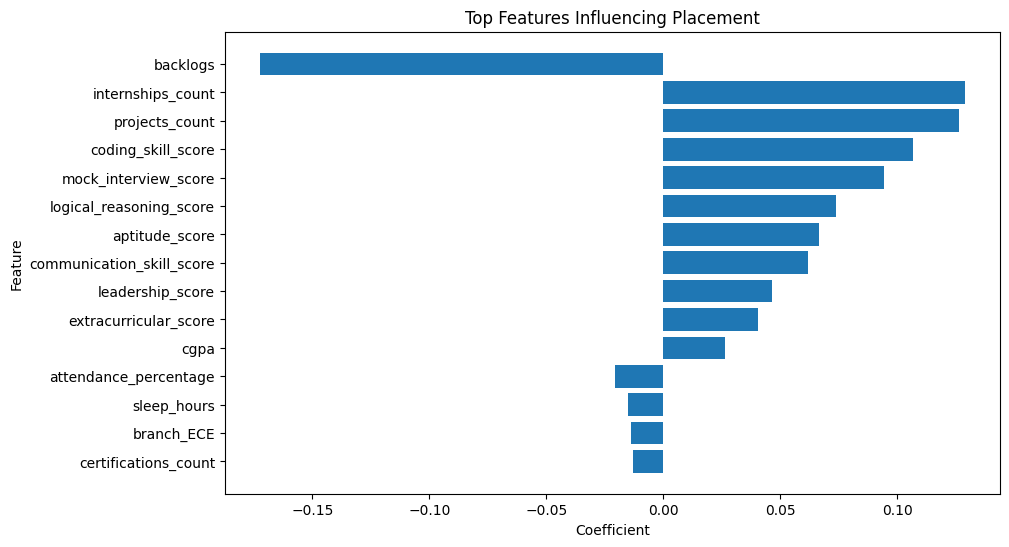

In [13]:
# Plot Top Features

top_features = importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Influencing Placement")
plt.gca().invert_yaxis()
plt.show()